In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score

# ==========================================
# 1. LOAD & SORT DATA
# ==========================================
df = pd.read_csv("df_cleaned.csv")
TARGET_COL = "phase"

print(f"Original Data Shape: {df.shape}")

# Sort by User and Day to ensure time-series logic is correct
df = df.sort_values(by=['id', 'day_in_study'])

# ==========================================
# 2. FEATURE ENGINEERING: TEMPORAL CONTEXT
# ==========================================
print("\nGenerating Temporal Features...")

# We focus on the most "cyclic" physiological signals
cols_to_lag = [
    'nightly_temperature', 
    'bpm_mean', 
    'bpm_min',
    'steps_daily', 
    'calories_daily',
    'efficiency' # Sleep efficiency
]

for col in cols_to_lag:
    # 1. Lag-1: "What was this value yesterday?"
    df[f'{col}_lag1'] = df.groupby('id')[col].shift(1)
    
    # 2. Rolling Mean (3 Days): "What is the recent trend?"
    df[f'{col}_roll3'] = df.groupby('id')[col].transform(lambda x: x.rolling(3).mean())

# ==========================================
# 3. HANDLE MISSING VALUES (First days of study)
# ==========================================
# Fill NaNs created by lag/rolling with the participant's median
for col in df.columns:
    if '_lag' in col or '_roll' in col:
        df[col] = df[col].fillna(df.groupby('id')[col].transform('median'))

# Final check to fill any remaining NaNs
df = df.fillna(0)

print(f"New Data Shape: {df.shape}")
new_cols = [c for c in df.columns if 'lag' in c or 'roll' in c]
print(f"Added {len(new_cols)} New Features: {new_cols}")

# ==========================================
# 4. DEFINE BASELINE FEATURE SET (With New Features)
# ==========================================
drop_cols_high_vif = [
    "composition_score", "revitalization_score", "duration_score", 
    "glucose_mean", "glucose_min", "glucose_std", 
    "minutesasleep", "duration_exercise", "calories_exercise"
]

# Create X and y
cols_to_drop = [c for c in drop_cols_high_vif if c in df.columns] + [TARGET_COL]
X = df.drop(columns=cols_to_drop)
y = df[TARGET_COL]

# ==========================================
# 4.5. FIX DATA TYPES 
# ==========================================
# Ensure all categorical columns are strictly strings to prevent "int vs str" error
cat_cols = X.select_dtypes(include=['object', 'category']).columns
for col in cat_cols:
    X[col] = X[col].astype(str)

print(f"\nFinal Feature Count: {X.shape[1]}")

# ==========================================
# 5. PREPROCESSING PIPELINE
# ==========================================
num_cols = X.select_dtypes(include=['int64', 'float64']).columns
# Re-select cat cols in case type conversion changed anything
cat_cols = X.select_dtypes(include=['object', 'category']).columns 

# Pipeline for Numeric: Impute -> Scale
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value=0)),
    ('scaler', StandardScaler())
])

# Pipeline for Categorical: Impute -> Encode
cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, num_cols),
    ('cat', cat_transformer, cat_cols)
])

# Encode Target
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Split Data (Stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# ==========================================
# 6. MODELING: XGBOOST
# ==========================================
print("\nTraining XGBoost with Temporal Features...")

xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=5,
    subsample=0.8,
    objective='multi:softprob',
    eval_metric='mlogloss',
    random_state=42
)

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', xgb_model)
])

pipeline.fit(X_train, y_train)

# ==========================================
# 7. EVALUATION
# ==========================================
y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)

acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba, multi_class='ovr', average='macro')

print("\n" + "="*30)
print("   RESULTS: TEMPORAL CONTEXT IMPROVEMENT")
print("="*30)
print(f"Test Accuracy: {acc:.4f}")
print(f"Macro AUC:     {auc:.4f}")
print("-" * 30)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

Original Data Shape: (2970, 61)

Generating Temporal Features...
New Data Shape: (2970, 73)
Added 12 New Features: ['nightly_temperature_lag1', 'nightly_temperature_roll3', 'bpm_mean_lag1', 'bpm_mean_roll3', 'bpm_min_lag1', 'bpm_min_roll3', 'steps_daily_lag1', 'steps_daily_roll3', 'calories_daily_lag1', 'calories_daily_roll3', 'efficiency_lag1', 'efficiency_roll3']

Final Feature Count: 63

Training XGBoost with Temporal Features...

   RESULTS: TEMPORAL CONTEXT IMPROVEMENT
Test Accuracy: 0.7037
Macro AUC:     0.9026
------------------------------

Classification Report:
              precision    recall  f1-score   support

   Fertility       0.68      0.56      0.62       131
  Follicular       0.67      0.73      0.70       161
      Luteal       0.72      0.80      0.76       191
   Menstrual       0.76      0.67      0.71       111

    accuracy                           0.70       594
   macro avg       0.71      0.69      0.70       594
weighted avg       0.70      0.70      0.7

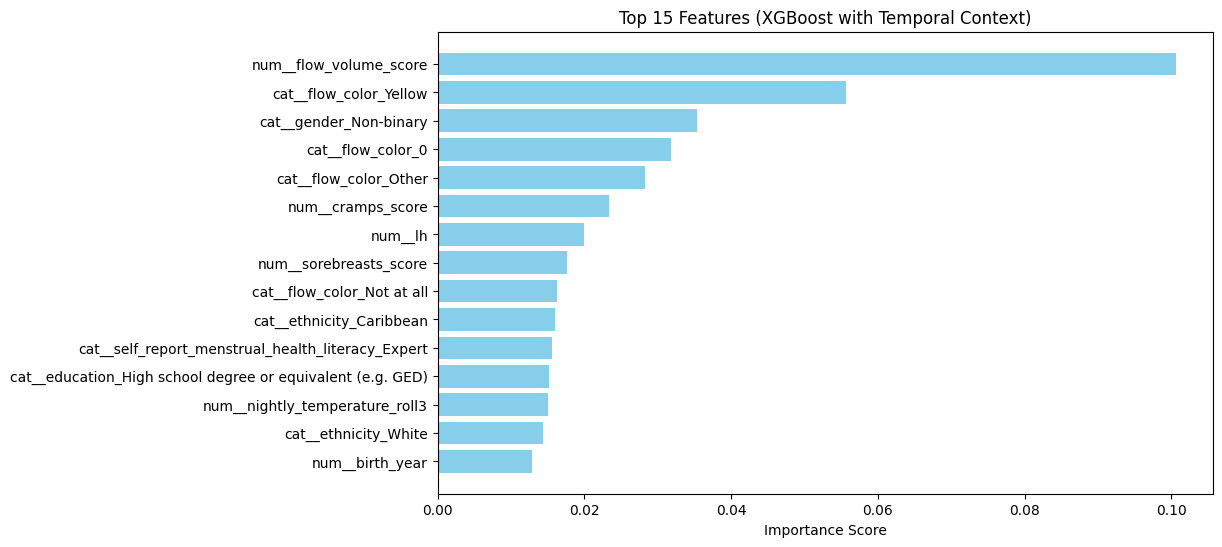

In [2]:
import matplotlib.pyplot as plt

# Get feature importance from the trained XGBoost model
# We access step 'classifier' because it's in a Pipeline
model = pipeline.named_steps['classifier']
feature_names = preprocessor.get_feature_names_out()

# Create a DataFrame
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': model.feature_importances_
})

# Sort and Plot Top 15
importance_df = importance_df.sort_values(by='Importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='skyblue')
plt.gca().invert_yaxis()
plt.title('Top 15 Features (XGBoost with Temporal Context)')
plt.xlabel('Importance Score')
plt.show()

In [3]:
importance_df

,Feature,Importance
30,num__flow_volume_score,0.100596
64,cat__flow_color_Yellow,0.055690
73,cat__gender_Non-binary,0.035350
55,cat__flow_color_0,0.031747
62,cat__flow_color_Other,0.028184
34,num__cramps_score,0.023366
2,num__lh,0.019904
35,num__sorebreasts_score,0.017667
60,cat__flow_color_Not at all,0.016244
77,cat__ethnicity_Caribbean,0.015920


Original Data Shape: (2970, 61)

Generating Temporal Features...
New Data Shape: (2970, 73)
Added 12 New Features: ['nightly_temperature_lag1', 'nightly_temperature_roll3', 'bpm_mean_lag1', 'bpm_mean_roll3', 'bpm_min_lag1', 'bpm_min_roll3', 'steps_daily_lag1', 'steps_daily_roll3', 'calories_daily_lag1', 'calories_daily_roll3', 'efficiency_lag1', 'efficiency_roll3']

Original Forward Selection Features: 29
Final Feature Count (with temporal): 41

Training Random Forest with Temporal Features (Forward Selection)...

   RESULTS: RF + FORWARD SELECTION + TEMPORAL
Test Accuracy: 0.6852
Macro AUC:     0.8822
------------------------------

Classification Report:
              precision    recall  f1-score   support

   Fertility       0.85      0.47      0.61       131
  Follicular       0.65      0.67      0.66       161
      Luteal       0.64      0.85      0.73       191
   Menstrual       0.73      0.67      0.70       111

    accuracy                           0.69       594
   macro 

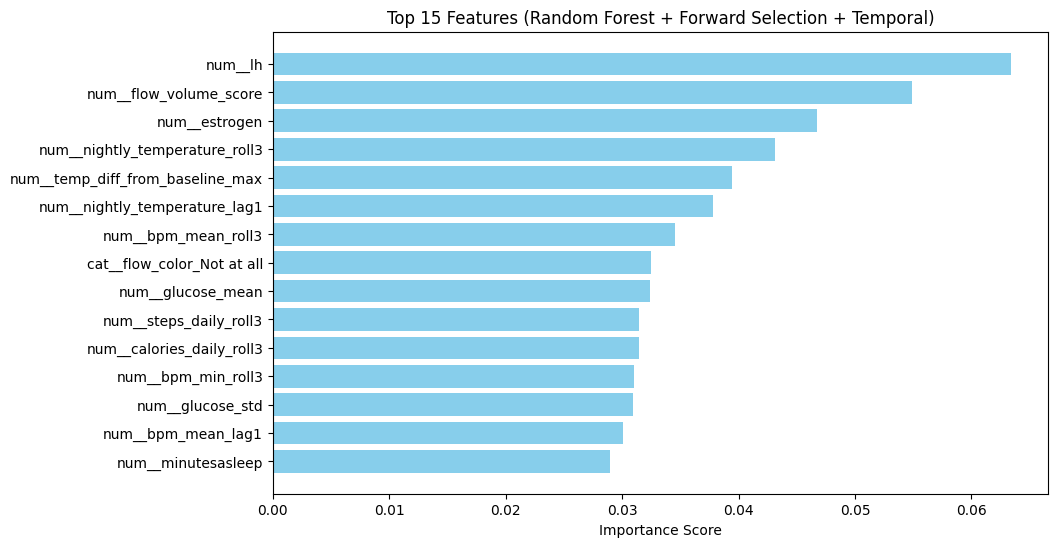


Top 15 Most Important Features:
                         Feature  Importance
                         num__lh    0.063396
          num__flow_volume_score    0.054917
                   num__estrogen    0.046698
  num__nightly_temperature_roll3    0.043090
num__temp_diff_from_baseline_max    0.039457
   num__nightly_temperature_lag1    0.037767
             num__bpm_mean_roll3    0.034536
      cat__flow_color_Not at all    0.032490
               num__glucose_mean    0.032388
          num__steps_daily_roll3    0.031461
       num__calories_daily_roll3    0.031443
              num__bpm_min_roll3    0.030981
                num__glucose_std    0.030909
              num__bpm_mean_lag1    0.030084
              num__minutesasleep    0.028972


In [4]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score
import matplotlib.pyplot as plt

# ==========================================
# 1. LOAD & SORT DATA
# ==========================================
df = pd.read_csv("df_cleaned.csv")
TARGET_COL = "phase"

print(f"Original Data Shape: {df.shape}")

# Sort by User and Day to ensure time-series logic is correct
df = df.sort_values(by=['id', 'day_in_study'])

# ==========================================
# 2. FEATURE ENGINEERING: TEMPORAL CONTEXT
# ==========================================
print("\nGenerating Temporal Features...")

# We focus on the most "cyclic" physiological signals
cols_to_lag = [
    'nightly_temperature', 
    'bpm_mean', 
    'bpm_min',
    'steps_daily', 
    'calories_daily',
    'efficiency' # Sleep efficiency
]

for col in cols_to_lag:
    # 1. Lag-1: "What was this value yesterday?"
    df[f'{col}_lag1'] = df.groupby('id')[col].shift(1)
    
    # 2. Rolling Mean (3 Days): "What is the recent trend?"
    df[f'{col}_roll3'] = df.groupby('id')[col].transform(lambda x: x.rolling(3).mean())

# ==========================================
# 3. HANDLE MISSING VALUES (First days of study)
# ==========================================
# Fill NaNs created by lag/rolling with the participant's median
for col in df.columns:
    if '_lag' in col or '_roll' in col:
        df[col] = df[col].fillna(df.groupby('id')[col].transform('median'))

# Final check to fill any remaining NaNs
df = df.fillna(0)

print(f"New Data Shape: {df.shape}")
new_cols = [c for c in df.columns if 'lag' in c or 'roll' in c]
print(f"Added {len(new_cols)} New Features: {new_cols}")

# ==========================================
# 4. DEFINE FORWARD SELECTION FEATURE SET (With New Features)
# ==========================================
# Original Forward Selection features
forward_features_base = [
    'lh', 'estrogen', 'calories_daily', 'temp_diff_from_baseline_max', 
    'glucose_mean', 'glucose_std', 'revitalization_score', 
    'minutestofallasleep', 'minutesasleep', 'minutesafterwakeup', 
    'duration_exercise', 'calories_exercise', 'heartrate_exercise', 
    'in_default_zone_3', 'in_default_zone_2', 'flow_volume_score', 
    'appetite_score', 'cramps_score', 'sorebreasts_score', 'fatigue_score', 
    'sleepissue_score', 'foodcravings_score', 'flow_color', 'activity_type', 
    'gender', 'ethnicity', 'education', 'sexually_active', 
    'self_report_menstrual_health_literacy'
]

# Add temporal features to Forward Selection
forward_features_temporal = forward_features_base + new_cols

# Verify all features exist in df
forward_features_temporal = [f for f in forward_features_temporal if f in df.columns]

# Create X and y
X = df[forward_features_temporal].copy()
y = df[TARGET_COL]

# ==========================================
# 4.5. FIX DATA TYPES 
# ==========================================
# Ensure all categorical columns are strictly strings to prevent "int vs str" error
cat_cols = X.select_dtypes(include=['object', 'category']).columns
for col in cat_cols:
    X[col] = X[col].astype(str)

print(f"\nOriginal Forward Selection Features: 29")
print(f"Final Feature Count (with temporal): {X.shape[1]}")

# ==========================================
# 5. PREPROCESSING PIPELINE
# ==========================================
num_cols = X.select_dtypes(include=['int64', 'float64']).columns
# Re-select cat cols in case type conversion changed anything
cat_cols = X.select_dtypes(include=['object', 'category']).columns 

# Pipeline for Numeric: Impute -> Scale
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value=0)),
    ('scaler', StandardScaler())
])

# Pipeline for Categorical: Impute -> Encode
cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, num_cols),
    ('cat', cat_transformer, cat_cols)
])

# Encode Target
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Split Data (Stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# ==========================================
# 6. MODELING: RANDOM FOREST
# ==========================================
print("\nTraining Random Forest with Temporal Features (Forward Selection)...")

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    class_weight='balanced',
    random_state=42
)

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', rf_model)
])

pipeline.fit(X_train, y_train)

# ==========================================
# 7. EVALUATION
# ==========================================
y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)

acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba, multi_class='ovr', average='macro')

print("\n" + "="*30)
print("   RESULTS: RF + FORWARD SELECTION + TEMPORAL")
print("="*30)
print(f"Test Accuracy: {acc:.4f}")
print(f"Macro AUC:     {auc:.4f}")
print("-" * 30)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

print("\n" + "="*50)
print("COMPARISON:")
print("="*50)
print(f"RF + Forward (Pre-tuning):    65.99% accuracy")
print(f"RF + Forward (Tuned):         65.66% accuracy")
print(f"RF + Forward (+ Temporal):    {acc:.2%} accuracy")
print(f"Improvement over baseline:    {(acc - 0.6599)*100:+.2f} percentage points")
print("="*50)

# ==========================================
# 8. FEATURE IMPORTANCE
# ==========================================
# Get feature importance from the trained Random Forest model
# We access step 'classifier' because it's in a Pipeline
model = pipeline.named_steps['classifier']
feature_names = preprocessor.get_feature_names_out()

# Create a DataFrame
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': model.feature_importances_
})

# Sort and Plot Top 15
importance_df = importance_df.sort_values(by='Importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='skyblue')
plt.gca().invert_yaxis()
plt.title('Top 15 Features (Random Forest + Forward Selection + Temporal)')
plt.xlabel('Importance Score')
plt.show()

# Print top features
print("\nTop 15 Most Important Features:")
print(importance_df.to_string(index=False))